## Install deps

> Run and activate conda env before

In [43]:
%pip install scikit-learn matplotlib numpy pandas

Note: you may need to restart the kernel to use updated packages.


In [44]:
import pandas as pd
import matplotlib.pyplot as plt

In [45]:
pumpkins = pd.read_csv("./US-pumpkins.csv")
pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [46]:
pumpkins.isnull().sum()

City Name             0
Type               1712
Package               0
Variety               5
Sub Variety        1461
Grade              1757
Date                  0
Low Price             0
High Price            0
Mostly Low          103
Mostly High         103
Origin                3
Origin District    1626
Item Size           279
Color               616
Environment        1757
Unit of Sale       1595
Quality            1757
Condition          1757
Appearance         1757
Storage            1757
Crop               1757
Repack                0
Trans Mode         1757
Unnamed: 24        1757
Unnamed: 25        1654
dtype: int64

In [47]:
columns_to_select = ["Package", "Low Price", "High Price", "Date"]
pumpkins = pumpkins.loc[:, columns_to_select]
pumpkins.head()

,Package,Low Price,High Price,Date
0,24 inch bins,270.0,280.0,4/29/17
1,24 inch bins,270.0,280.0,5/6/17
2,24 inch bins,160.0,160.0,9/24/16
3,24 inch bins,160.0,160.0,9/24/16
4,24 inch bins,90.0,100.0,11/5/16


In [48]:
pumpkins.isnull().sum()

Package       0
Low Price     0
High Price    0
Date          0
dtype: int64

In [49]:
price = (pumpkins["Low Price"] + pumpkins["High Price"]) / 2

month = pd.DatetimeIndex(pumpkins["Date"]).month

avg_price_df = pd.DataFrame(
    data=({"Price": price, "Month": month}), columns=("Price", "Month")
)
avg_price_df.sort_values("Month")
avg_price_df.head()

,Price,Month
0,275.0,4
1,275.0,5
2,160.0,9
3,160.0,9
4,95.0,11


In [50]:
new_pumpkins = pd.DataFrame(
    {
        "Month": month,
        "Package": pumpkins["Package"],
        "Low Price": pumpkins["Low Price"],
        "High Price": pumpkins["High Price"],
        "Price": price,
    }
)

new_pumpkins.head()

,Month,Package,Low Price,High Price,Price
0,4,24 inch bins,270.0,280.0,275.0
1,5,24 inch bins,270.0,280.0,275.0
2,9,24 inch bins,160.0,160.0,160.0
3,9,24 inch bins,160.0,160.0,160.0
4,11,24 inch bins,90.0,100.0,95.0


In [51]:
new_pumpkins = new_pumpkins[
    pumpkins["Package"].str.contains("bushel", case=True, regex=True)
]

new_pumpkins.head()

,Month,Package,Low Price,High Price,Price
70,9,1 1/9 bushel cartons,15.0,15.0,15.0
71,9,1 1/9 bushel cartons,18.0,18.0,18.0
72,10,1 1/9 bushel cartons,18.0,18.0,18.0
73,10,1 1/9 bushel cartons,17.0,17.0,17.0
74,10,1 1/9 bushel cartons,15.0,15.0,15.0


In [52]:
new_pumpkins.loc[new_pumpkins["Package"].str.contains("1 1/9"), "Price"] = price / (
    1 + 1 / 9
)

new_pumpkins.loc[new_pumpkins["Package"].str.contains("1/2"), "Price"] = price / (1 / 2)

Text(0, 0.5, 'Pumpkin Price')

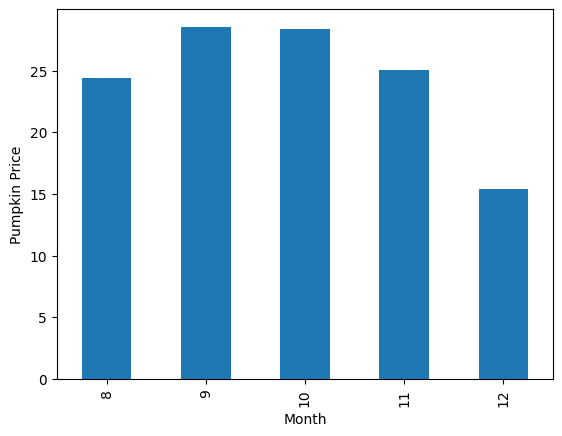

In [54]:
new_pumpkins.groupby(["Month"])["Price"].mean().plot(kind="bar")
plt.ylabel("Pumpkin Price")

Text(0, 0.5, 'Pumpkin Price')

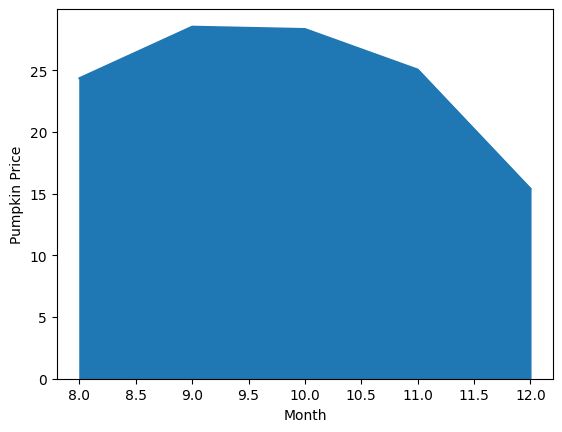

In [55]:
new_pumpkins.groupby(["Month"])["Price"].mean().plot(kind="area")
plt.ylabel("Pumpkin Price")

Text(0, 0.5, 'Pumpkin Price')

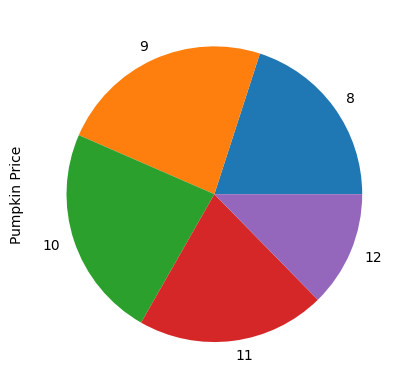

In [57]:
new_pumpkins.groupby(["Month"])["Price"].mean().plot(kind="pie")
plt.ylabel("Pumpkin Price")

Text(0, 0.5, 'Pumpkin Price')

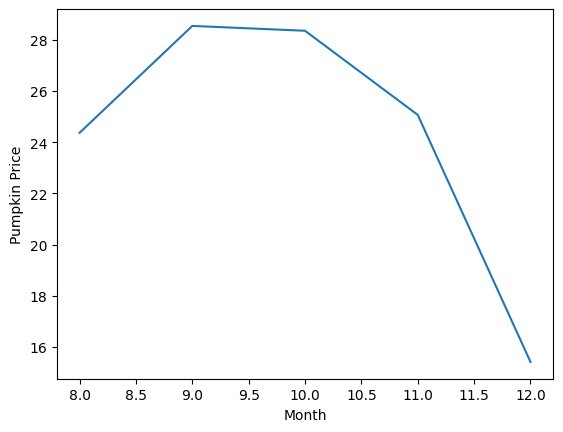

In [60]:
new_pumpkins.groupby(["Month"])["Price"].mean().plot(kind="line")
plt.ylabel("Pumpkin Price")